In [4]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt


In [5]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}
cols_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_clean = datos_penguins.dropna(subset=cols_numericas + ['species'])

Vamos a hacer un pairplot! El pairplot agarra de a pares de variables, y las grafica.
En la diagonal principal, realiza KDEs de las variables

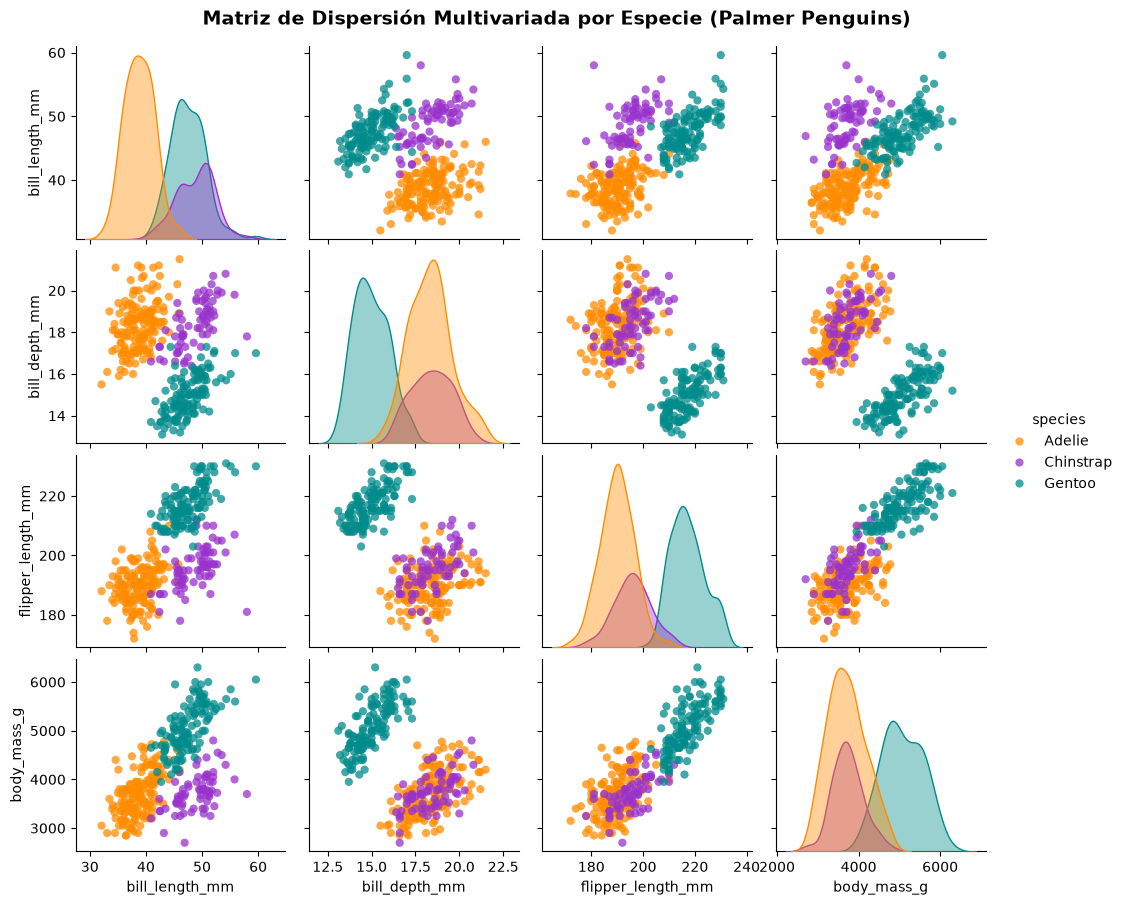

In [6]:
# 3. Generación del pairplot discriminando por especie
g = sns.pairplot(
    data=df_clean,
    vars=cols_numericas,
    hue='species',
    palette=paleta_penguins,
    diag_kind='kde',              # Densidad en la diagonal para ver separabilidad univariada
    plot_kws={'alpha': 0.75, 's': 35, 'edgecolor': 'none'},
    diag_kws={'fill': True, 'alpha': 0.4},
    height=2.3,
    aspect=1.1
)

# Ajuste de títulos y márgenes
g.fig.subplots_adjust(top=0.94)
g.fig.suptitle("Matriz de Dispersión Multivariada por Especie (Palmer Penguins)", fontsize=14, weight='bold')

plt.show()

En el pairplot, podemos ver que la especie mas separable es la Gentoo, y se vislumbra que el bill_length es una variable que nos podria permitir separar la raza Chinstrap de la raza Adelie, ya que sus picos son un poco mas largos.

Ahora, veamos el grafico de coordenadas paralelas, con los datos normalizados

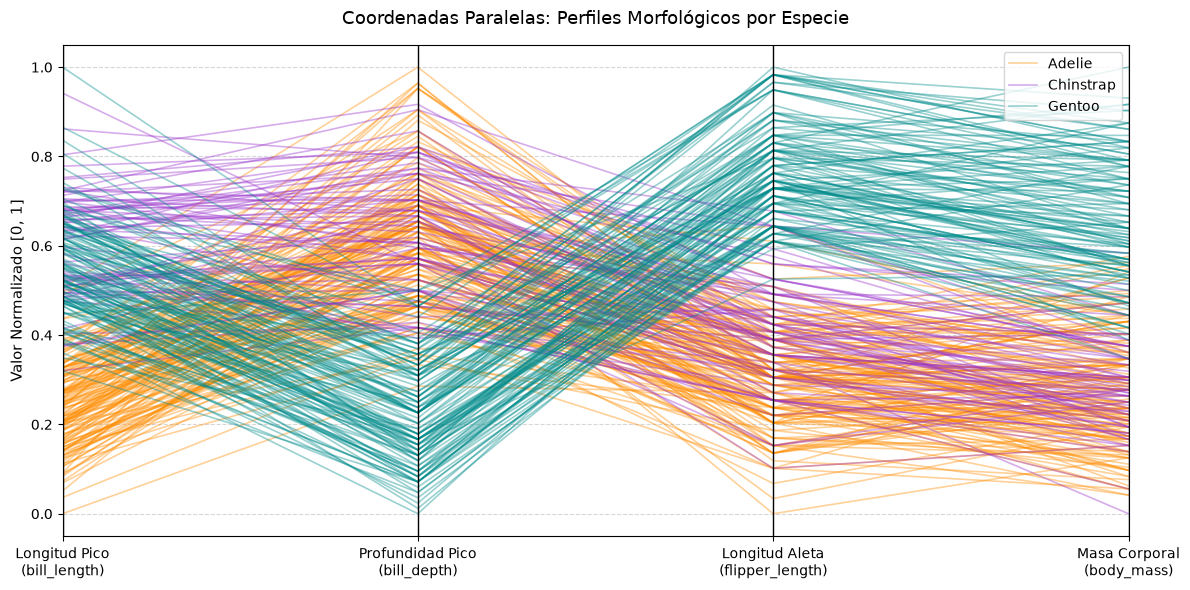

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

# 1. Definición explícita de columnas en orden
cols_morfologicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_clean = datos_penguins.dropna(subset=cols_morfologicas + ['species']).copy()

# 2. Normalización Min-Max [0, 1]
scaler = MinMaxScaler()
df_norm = df_clean.copy()
df_norm[cols_morfologicas] = scaler.fit_transform(df_clean[cols_morfologicas])

# 3. Gráfico asegurando el orden exacto de columnas
plt.figure(figsize=(12, 6))
paleta_colores = ['#FF8C00', '#9932CC', '#008B8B']  # Adelie, Chinstrap, Gentoo

parallel_coordinates(
    df_norm[['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']],
    class_column='species',
    color=paleta_colores,
    alpha=0.4,
    linewidth=1.2
)

plt.title("Coordenadas Paralelas: Perfiles Morfológicos por Especie", fontsize=13, pad=15)
plt.ylabel("Valor Normalizado [0, 1]", fontsize=11)
plt.xticks(
    ticks=range(len(cols_morfologicas)),
    labels=['Longitud Pico\n(bill_length)', 'Profundidad Pico\n(bill_depth)', 'Longitud Aleta\n(flipper_length)', 'Masa Corporal\n(body_mass)'],
    fontsize=10
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

En lo personal, no me parece un grafico tan lindo, pero podemos ver los perfiles de gento y adelie bastante "opuestos", mientra que el chinstrap, sigue la tendencia del adelie, pero comienza mas alto el largo del pico, y con aletas un poco mas largas, por lo que es menos "drastico" el cambio que se ve variable a variable.

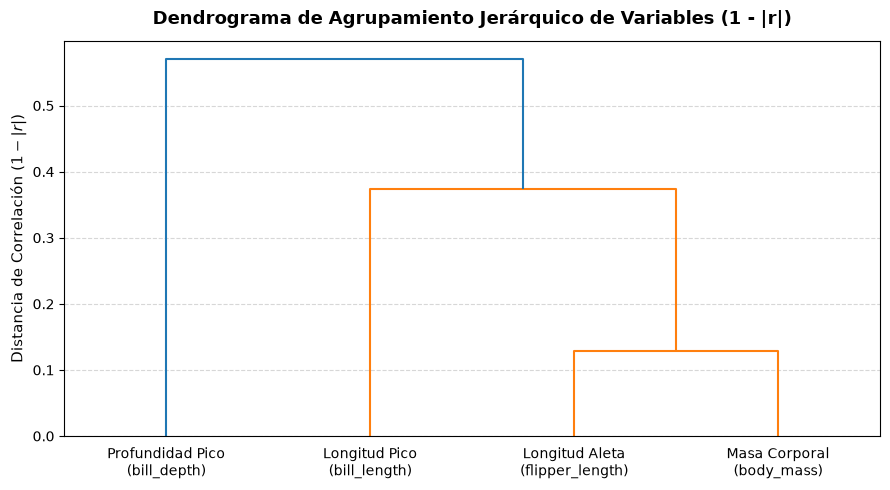

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# 1. Selección y limpieza de variables numéricas
cols_morfologicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_num = datos_penguins[cols_morfologicas].dropna()

# 2. Matriz de correlación de Pearson
matriz_corr = df_num.corr()

# 3. Conversión a matriz de distancia por correlación: d = 1 - |r|
# (usamos valor absoluto o (1 - r) para considerar la fuerza de la asociación lineal)
matriz_dist = 1 - np.abs(matriz_corr)

# Convertir la matriz simétrica a formato condensado (vector 1D) requerido por SciPy
dist_condensada = squareform(matriz_dist)

# 4. Cálculo del enlace jerárquico (método 'average' o 'complete')
Z = linkage(dist_condensada, method='average')

# 5. Visualización del Dendrograma
plt.figure(figsize=(9, 5))
dendrogram(
    Z,
    labels=[
        'Longitud Pico\n(bill_length)',
        'Profundidad Pico\n(bill_depth)',
        'Longitud Aleta\n(flipper_length)',
        'Masa Corporal\n(body_mass)'
    ],
    leaf_rotation=0,
    leaf_font_size=10,
    color_threshold=0.5  # Umbral para colorear clústeres
)

plt.title("Dendrograma de Agrupamiento Jerárquico de Variables (1 - |r|)", fontsize=13, weight='bold', pad=12)
plt.ylabel("Distancia de Correlación ($1 - |r|$)", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Vemos aca, que las variables que mejor se agrupan, son las 2 relacionadas al tamaño corporal del pinguino.

La varianle bill_depth, es la que menos "covaria" con los otros datos: si vemos el heatmap anterior, vemos que bill_depth con bill_length, es la correlacion mas baja de todas.

findfont: Failed to find font weight semibold, now using 700.


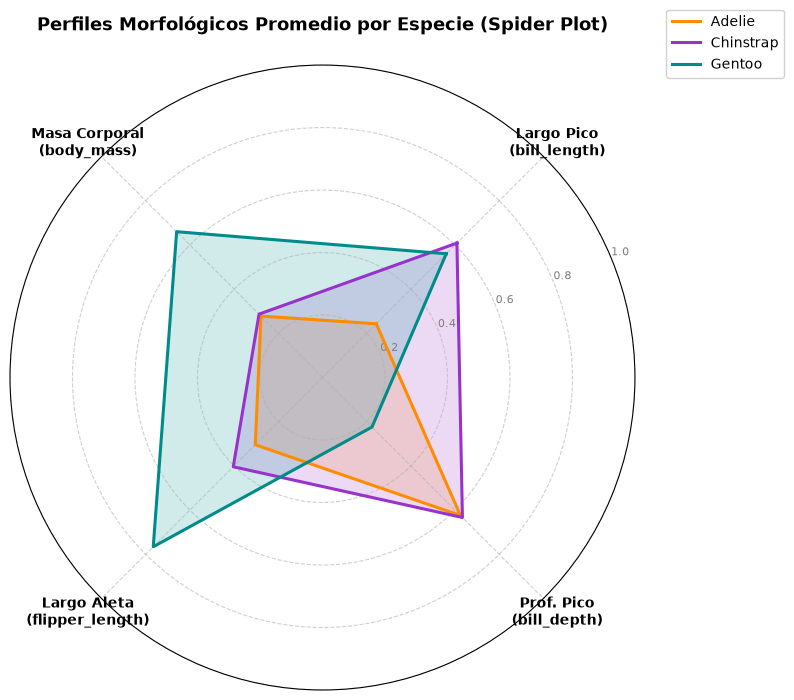

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Filtrado y normalización global [0, 1]
cols_morfologicas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_clean = datos_penguins.dropna(subset=cols_morfologicas + ['species']).copy()

scaler = MinMaxScaler()
df_norm = df_clean.copy()
df_norm[cols_morfologicas] = scaler.fit_transform(df_clean[cols_morfologicas])

# 2. Cálculo del promedio normalizado por especie
promedios = df_norm.groupby('species')[cols_morfologicas].mean()

# 3. Configuración de geometría polar
etiquetas = [
    'Largo Pico\n(bill_length)',
    'Prof. Pico\n(bill_depth)',
    'Largo Aleta\n(flipper_length)',
    'Masa Corporal\n(body_mass)'
]
num_vars = len(cols_morfologicas)

# Ángulos equiespaciados para cada eje (en radianes)
angulos = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
# Cerrar el lazo conectando el último punto con el primero
angulos += angulos[:1]

# 4. Construcción del Radar Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
paleta_penguins = {'Adelie': '#FF8C00', 'Chinstrap': '#9932CC', 'Gentoo': '#008B8B'}

for especie, color in paleta_penguins.items():
    valores = promedios.loc[especie].tolist()
    valores += valores[:1]  # Cerrar el polígono repitiendo el primer valor
    
    ax.plot(angulos, valores, label=especie, color=color, linewidth=2.2)
    ax.fill(angulos, valores, color=color, alpha=0.18)

# 5. Ajustes de formato y grilla
ax.set_theta_offset(np.pi / 4)           # Rotar para alinear estéticamente los 4 ejes
ax.set_theta_direction(-1)               # Sentido horario
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiquetas, fontsize=10, weight='semibold')

ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8, color='gray')
ax.grid(True, linestyle='--', alpha=0.6)

plt.title("Perfiles Morfológicos Promedio por Especie (Spider Plot)", fontsize=13, weight='bold', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), framealpha=0.9)
plt.tight_layout()
plt.show()

Aca se ve bien claro la diferencia! Los pinguinos chinstrap tienen picos mas largos, y aletas un poco mas largas que las de los Adelie!